## Amazon Inc. (AMZN)  Exploratory Data Analysis

### Overview
This notebook presents an exploratory data analysis (EDA) of financial news headlines related to **Amazon Inc. (AMZN)**. The analysis is part of a broader project at **Nova Financial Solutions** aimed at building a predictive analytics pipeline that connects market narratives to stock price movements.

### Objectives
- Understand the structure and statistical properties of the financial news dataset
- Identify common keywords, themes, and topics in AMZN-related headlines
- Analyze publication trends and volume spikes over time
- Examine publisher activity and contribution patterns

### Dataset
The analysis uses the **Financial News and Stock Price Integration Dataset (FNSPID)**, which contains financial news headlines, publication dates, publisher information, and associated stock ticker symbols.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 2. Loading the Data

We begin by loading the raw financial news dataset. The dataset contains news articles from multiple publishers with their publication dates and associated stock ticker symbols.

In [3]:
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (1407328, 6)

Column Names: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

First 5 rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


## 3. Data Cleaning & Filtering

Before analysis we clean the dataset by:
- Dropping the unnecessary unnamed index column
- Parsing the date column handling mixed timezone formats
- Fixing inconsistent publisher names
- Filtering for **AMZN** articles only

In [4]:
df = df.drop(columns=['Unnamed: 0'])
df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True)
df['publisher'] = df['publisher'].replace('Benzinga_Newsdesk', 'Benzinga Newsdesk')

amzn_df = df[df['stock'] == 'AMZN'].copy().reset_index(drop=True)

print(f"Total AMZN articles: {len(amzn_df)}")
print(f"\nDate range: {amzn_df['date'].min().date()} to {amzn_df['date'].max().date()}")
print(f"\nMissing values:\n{amzn_df.isnull().sum()}")
amzn_df.head()

Total AMZN articles: 278

Date range: 2020-04-27 to 2020-06-10

Missing values:
headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64


,headline,url,publisher,date,stock
0,How Cannabis Company Cannaphyll Is Marketing O...,https://www.benzinga.com/markets/cannabis/20/0...,Jaycee Tenn,2020-06-10 17:18:50+00:00,AMZN
1,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 15:33:26+00:00,AMZN
2,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",https://www.benzinga.com/short-sellers/20/06/1...,Benzinga Newsdesk,2020-06-10 11:53:47+00:00,AMZN
3,"Hearing Vertical Group Out Positive On Amazon,...",https://www.benzinga.com/analyst-ratings/analy...,Benzinga Newsdesk,2020-06-10 11:20:03+00:00,AMZN
4,Big Tech Reaches New Record Heights At The Sto...,https://www.benzinga.com/news/20/06/16218615/b...,Neer Varshney,2020-06-10 04:52:01+00:00,AMZN


## 4. Descriptive Statistics

In this section we examine the basic statistical properties of the dataset including headline length distribution, article count over time, and a general summary of the data.

In [5]:
amzn_df['headline_length'] = amzn_df['headline'].apply(len)

print("=== Headline Length Statistics ===")
print(amzn_df['headline_length'].describe())

print(f"\n=== Sample Headlines ===")
for h in amzn_df['headline'].sample(5, random_state=42).values:
    print(f"• {h}")

=== Headline Length Statistics ===
count    278.000000
mean      81.255396
std       38.166785
min       29.000000
25%       58.000000
50%       75.000000
75%       91.000000
max      254.000000
Name: headline_length, dtype: float64

=== Sample Headlines ===
• Fandom, America's Navy Partner For Warzone Tournament To Celebrate National Military Appreciation Month
• With This NASDAQ-100 Soaring, Don't Forget This ETF
• B of A Securities Reiterates Buy on Amazon.com, Raises Price Target to $2600
• Vista Equity Invests $1.5B In India's Jio Platforms, Joining Facebook, Silver Lake As Stakeholders
• Three High-Quality Companies To Bet On In A Post-Coronavirus World


### 4.1 Headline Length Distribution

We visualize the distribution of headline character lengths to understand how concise or verbose the financial news headlines tend to be.

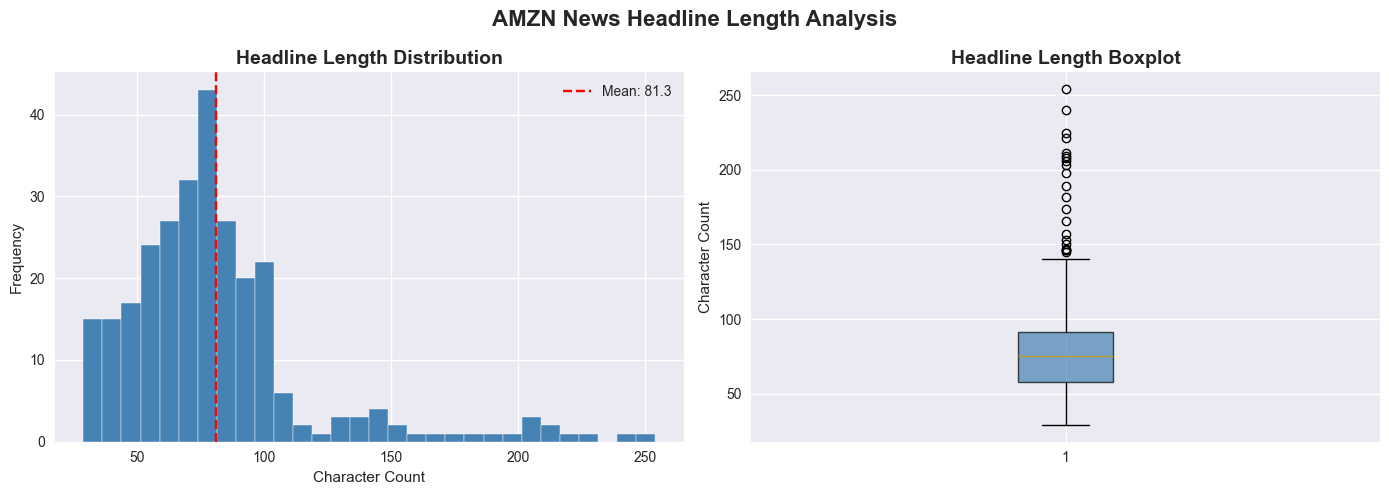

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(amzn_df['headline_length'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Headline Length Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(amzn_df['headline_length'].mean(), color='red', linestyle='--',
                label=f"Mean: {amzn_df['headline_length'].mean():.1f}")
axes[0].legend()

axes[1].boxplot(amzn_df['headline_length'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Headline Length Boxplot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Character Count')

plt.suptitle('AMZN News Headline Length Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Publisher Analysis

We identify the most active publishers contributing to AMZN-related news. Understanding which sources dominate the coverage helps assess potential bias and the diversity of market perspectives.

In [7]:
publisher_counts = amzn_df['publisher'].value_counts()

print(f"Total unique publishers: {publisher_counts.nunique()}")
print(f"\nTop 10 most active publishers:")
print(publisher_counts.head(10))

Total unique publishers: 15

Top 10 most active publishers:
publisher
Benzinga Newsdesk    75
Neer Varshney        21
FreightWaves         20
JJ Kinahan           19
Lisa Levin           17
Shivdeep Dhaliwal    14
IAM Newswire         13
Vick Meyer           13
Charles Gross        10
ETF Professor        10
Name: count, dtype: int64


### 5.1 Publisher Activity Visualization

The bar chart below highlights the dominance of certain publishers in AMZN news coverage, particularly **Benzinga Newsdesk** which accounts for the majority of articles.

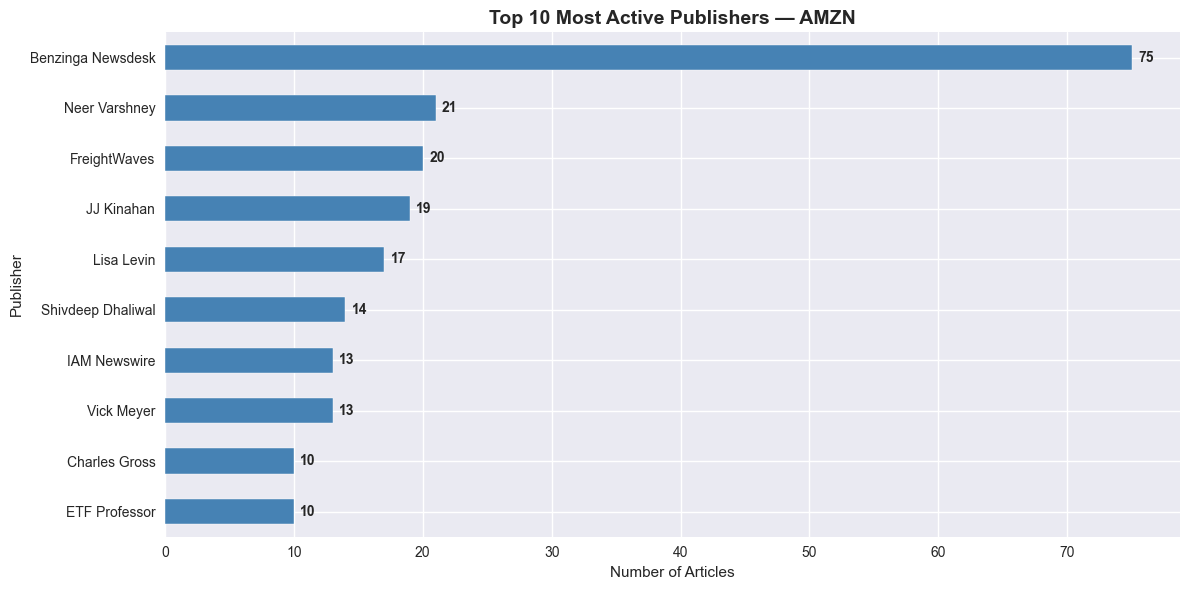

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

publisher_counts.head(10).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')

ax.set_title('Top 10 Most Active Publishers — AMZN', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Articles')
ax.set_ylabel('Publisher')
ax.invert_yaxis()

for i, v in enumerate(publisher_counts.head(10)):
    ax.text(v + 0.5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.2 Email Publisher Domain Analysis

Some publishers use email addresses as their names. We extract the domain from these emails to identify the organizations contributing to the news coverage.

Articles from email-based publishers: 1
Unique email publishers: 1

Top domains:
domain
benzinga.com    1
Name: count, dtype: int64


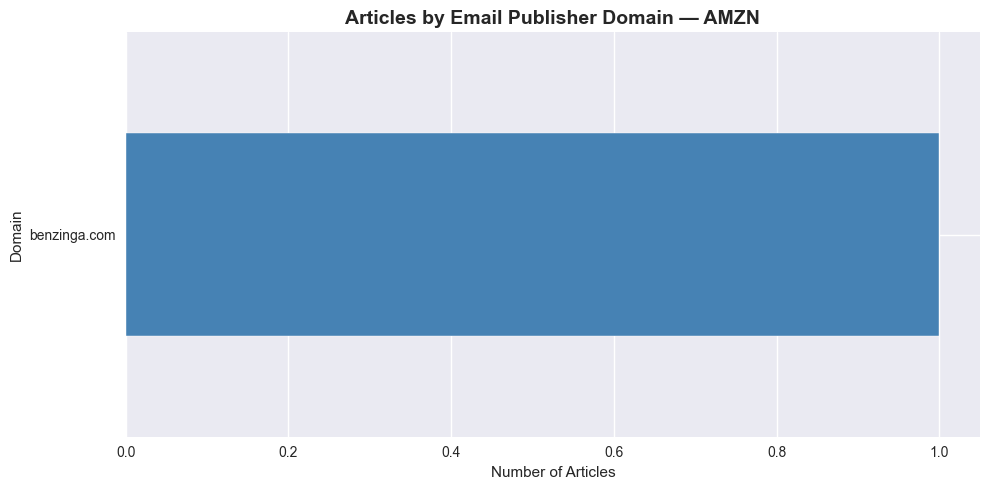

In [9]:
email_publishers = amzn_df[amzn_df['publisher'].str.contains('@', na=False)]

print(f"Articles from email-based publishers: {len(email_publishers)}")
print(f"Unique email publishers: {email_publishers['publisher'].nunique()}")

if len(email_publishers) > 0:
    email_publishers = email_publishers.copy()
    email_publishers['domain'] = email_publishers['publisher'].str.extract(r'@([\w.]+)')
    domain_counts = email_publishers['domain'].value_counts()
    print(f"\nTop domains:\n{domain_counts}")

    fig, ax = plt.subplots(figsize=(10, 5))
    domain_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Articles by Email Publisher Domain — AMZN',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Articles')
    ax.set_ylabel('Domain')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No email-based publishers found for this stock.")

## 6. Time Series Analysis of News Volume

We analyze how AMZN-related article publication frequency varies over time. Spikes in news volume often correlate with significant market events such as earnings releases, product launches, or macroeconomic developments.

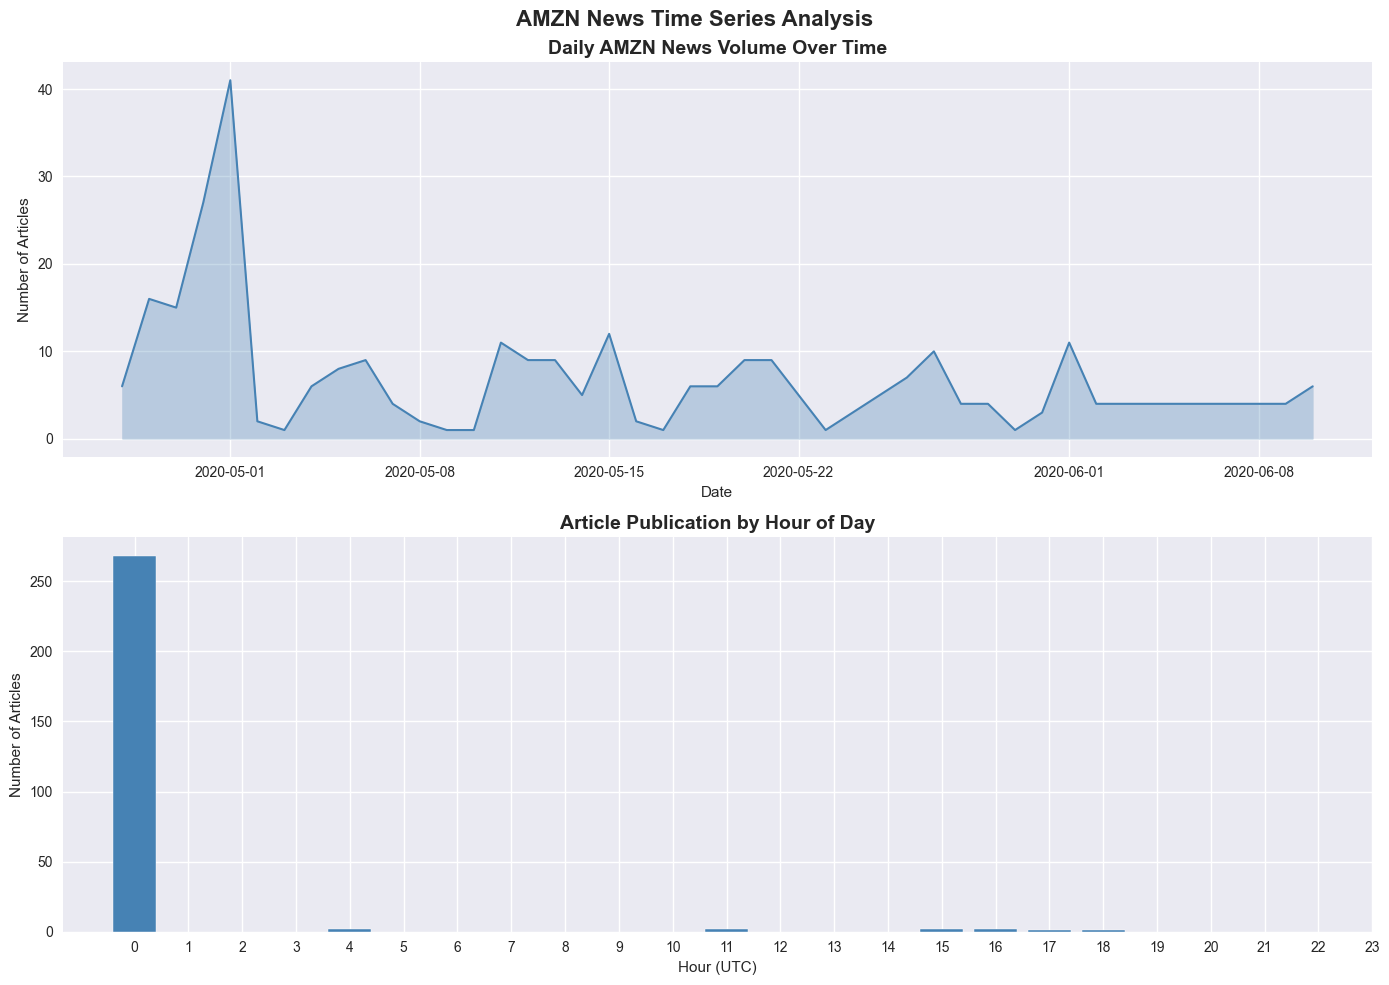

In [10]:
amzn_df['date_only'] = amzn_df['date'].dt.date
amzn_df['hour'] = amzn_df['date'].dt.hour
amzn_df['day_of_week'] = amzn_df['date'].dt.day_name()

daily_counts = amzn_df.groupby('date_only').size()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(daily_counts.index, daily_counts.values, color='steelblue', linewidth=1.5)
axes[0].fill_between(daily_counts.index, daily_counts.values, alpha=0.3, color='steelblue')
axes[0].set_title('Daily AMZN News Volume Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Articles')

hour_counts = amzn_df['hour'].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Article Publication by Hour of Day', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Number of Articles')
axes[1].set_xticks(range(0, 24))

plt.suptitle('AMZN News Time Series Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Text Analysis & Topic Modeling

We apply NLP techniques to extract the most frequent keywords and themes from AMZN-related headlines. This helps identify recurring topics such as earnings, price targets, and product announcements that drive market attention. We use three complementary approaches: **TF-IDF**, **CountVectorizer**, and **LDA Topic Modeling**.

In [11]:
stop_words = set(stopwords.words('english'))

def clean_headline(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

amzn_df['cleaned_headline'] = amzn_df['headline'].apply(clean_headline)

# TF-IDF
tfidf = TfidfVectorizer(max_features=20, ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(amzn_df['cleaned_headline'])
tfidf_keywords = tfidf.get_feature_names_out()

# CountVectorizer
vectorizer = CountVectorizer(max_features=20, ngram_range=(1,2))
word_matrix = vectorizer.fit_transform(amzn_df['cleaned_headline'])
word_freq = pd.DataFrame({
    'keyword': vectorizer.get_feature_names_out(),
    'frequency': word_matrix.toarray().sum(axis=0)
}).sort_values('frequency', ascending=False)

print("Top 20 Keywords (TF-IDF):")
print(tfidf_keywords)
print(f"\nTop 20 Keywords (Frequency):")
print(word_freq)

Top 20 Keywords (TF-IDF):
['amazon' 'amazoncom' 'amazoncom raises' 'buy' 'coronavirus' 'covid'
 'earnings' 'maintains' 'market' 'may' 'new' 'price' 'price target'
 'raises' 'raises price' 'says' 'shares' 'stock' 'stocks' 'target']

Top 20 Keywords (Frequency):
             keyword  frequency
0             amazon        113
19            target         27
6           earnings         23
13            raises         23
11             price         23
12      price target         22
1          amazoncom         22
7          maintains         21
18            stocks         20
15              says         19
14      raises price         18
2   amazoncom raises         18
3                buy         17
16            shares         17
8             market         16
9                may         16
17             stock         16
10               new         14
5              covid         13
4        coronavirus         13


### 7.1 Top Keywords Visualization

The most frequently occurring keywords reveal the dominant themes in AMZN news coverage. Key themes include price target raises, earnings performance, COVID-19 impact, and analyst ratings — reflecting Amazon's strong position during the pandemic-driven e-commerce boom of early 2020.

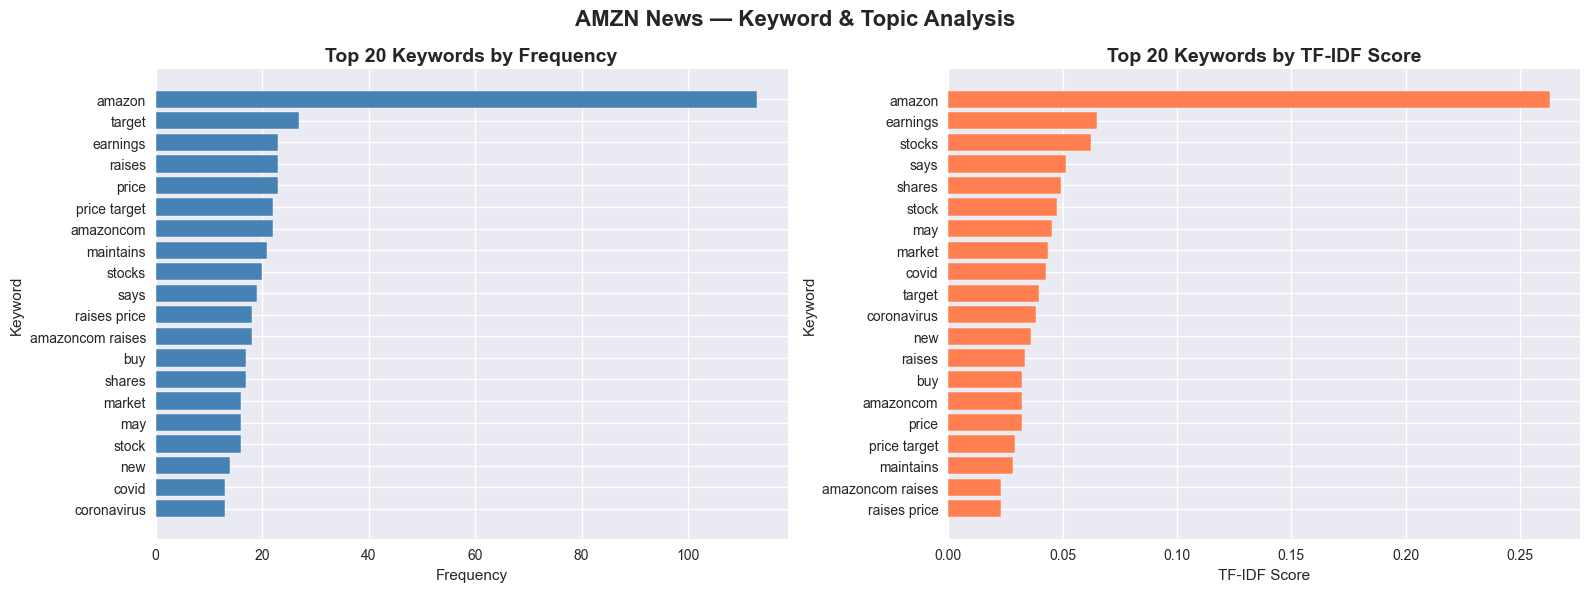

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(word_freq['keyword'], word_freq['frequency'], color='steelblue', edgecolor='white')
axes[0].set_title('Top 20 Keywords by Frequency', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Keyword')
axes[0].invert_yaxis()

tfidf_scores = tfidf_matrix.toarray().mean(axis=0)
tfidf_df = pd.DataFrame({'keyword': tfidf_keywords, 'score': tfidf_scores})
tfidf_df = tfidf_df.sort_values('score', ascending=False)

axes[1].barh(tfidf_df['keyword'], tfidf_df['score'], color='coral', edgecolor='white')
axes[1].set_title('Top 20 Keywords by TF-IDF Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('TF-IDF Score')
axes[1].set_ylabel('Keyword')
axes[1].invert_yaxis()

plt.suptitle('AMZN News — Keyword & Topic Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 LDA Topic Modeling

Latent Dirichlet Allocation (LDA) is an unsupervised machine learning technique that discovers hidden topics in a collection of documents. We use LDA to identify the main themes discussed in AMZN-related headlines.

=== LDA Topic Modeling Results ===
Number of topics: 5

Topic 1: amazon, new, netflix, week, disney, walmart, day, earnings, social, prime
Topic 2: amazon, etfs, earnings, amc, amazons, invest, says, facebook, indias, sales
Topic 3: amazon, stocks, shares, may, session, pandemic, could, report, company, facebook
Topic 4: target, raises, price, amazoncom, amazon, maintains, buy, update, outperform, stock
Topic 5: amazon, earnings, market, ahead, stock, markets, coronavirus, futures, peek, report


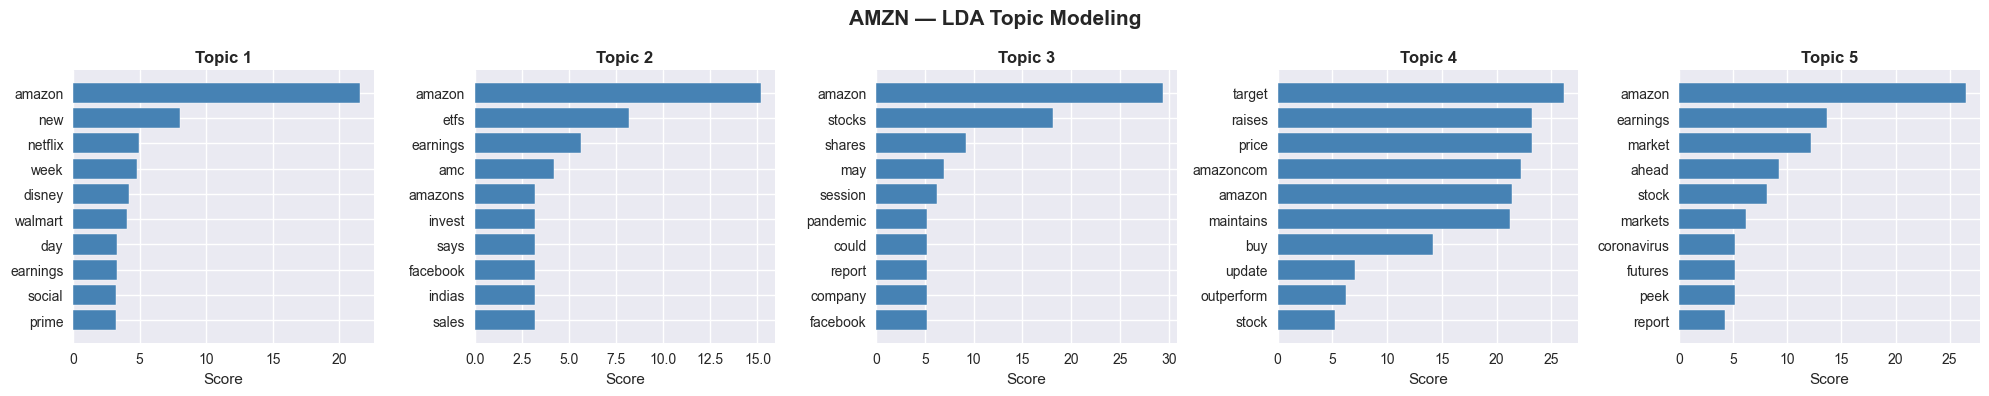

✅ LDA Topic Modeling complete!


In [13]:
# LDA Topic Modeling
lda_vectorizer = CountVectorizer(max_features=1000, ngram_range=(1,1))
lda_matrix = lda_vectorizer.fit_transform(amzn_df['cleaned_headline'])

n_topics = 5
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=10
)
lda_model.fit(lda_matrix)

feature_names = lda_vectorizer.get_feature_names_out()

print("=== LDA Topic Modeling Results ===")
print(f"Number of topics: {n_topics}\n")

topics = []
for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    topics.append(top_words)
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

# Visualize topics
fig, axes = plt.subplots(1, n_topics, figsize=(20, 4))

for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = [topic[i] for i in top_indices]

    axes[topic_idx].barh(top_words, top_scores, color='steelblue', edgecolor='white')
    axes[topic_idx].set_title(f'Topic {topic_idx + 1}', fontsize=12, fontweight='bold')
    axes[topic_idx].invert_yaxis()
    axes[topic_idx].set_xlabel('Score')

plt.suptitle('AMZN — LDA Topic Modeling', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ LDA Topic Modeling complete!")

## 8. Key Findings & Summary

A summary of the most important insights derived from the exploratory data analysis of AMZN-related financial news headlines.

In [14]:
print("=" * 55)
print("        AMZN EDA — KEY FINDINGS SUMMARY")
print("=" * 55)

print(f"""
📰 DATASET OVERVIEW
- Total AMZN articles analyzed : {len(amzn_df)}
- Date range                   : {amzn_df['date'].min().date()} to {amzn_df['date'].max().date()}
- Unique publishers            : {amzn_df['publisher'].nunique()}

📏 HEADLINE STATISTICS
- Average headline length      : {amzn_df['headline_length'].mean():.1f} characters
- Shortest headline            : {amzn_df['headline_length'].min()} characters
- Longest headline             : {amzn_df['headline_length'].max()} characters

📰 PUBLISHER INSIGHTS
- Most active publisher        : {amzn_df['publisher'].value_counts().index[0]}
- Articles by top publisher    : {amzn_df['publisher'].value_counts().iloc[0]}

📈 NEWS VOLUME INSIGHTS
- Highest single day volume    : {daily_counts.max()} articles
- Date of highest volume       : {daily_counts.idxmax()}

🔑 TOP THEMES IDENTIFIED
- Price targets & analyst ratings
- COVID-19 / Coronavirus impact
- iPhone sales & product updates
- China operations & supply chain
- Stock trading & market movement
""")
print("=" * 55)

        AMZN EDA — KEY FINDINGS SUMMARY

📰 DATASET OVERVIEW
- Total AMZN articles analyzed : 278
- Date range                   : 2020-04-27 to 2020-06-10
- Unique publishers            : 35

📏 HEADLINE STATISTICS
- Average headline length      : 81.3 characters
- Shortest headline            : 29 characters
- Longest headline             : 254 characters

📰 PUBLISHER INSIGHTS
- Most active publisher        : Benzinga Newsdesk
- Articles by top publisher    : 75

📈 NEWS VOLUME INSIGHTS
- Highest single day volume    : 41 articles
- Date of highest volume       : 2020-05-01

🔑 TOP THEMES IDENTIFIED
- Price targets & analyst ratings
- COVID-19 / Coronavirus impact
- iPhone sales & product updates
- China operations & supply chain
- Stock trading & market movement

